# MediCare Patient Follow-Up Agent

**Candidate:** Kushagra Singh  
**Role:** AI/ML Engineer - Publicis Sapient case study

This notebook uses an LLM agent to review patient records, call analysis tools and prepare prioritised follow-up actions.

## How it works

1. The LLM receives the task and tool definitions.
2. It chooses which patient, lab and vital-sign tools to call.
3. Tool results are returned to the LLM until it records a validated follow-up action and writes the report.

Patient names are removed before records are sent to the model. The API key is loaded from the environment and is not stored in the notebook.

**Run:** use Python 3.10+ with Jupyter, install `pandas matplotlib openai pydantic python-dotenv`, place `patient_data.csv` beside the notebook, set `OPENAI_API_KEY`, then choose *Restart & Run All*. The default model is `gpt-4.1-mini`.

> This is a decision-support prototype. A clinician must review every recommendation.

In [1]:
import json, logging, os, sys, time
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any, Callable, Literal
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display
from openai import APIError, OpenAI
from pydantic import BaseModel, Field, ValidationError

class MediCareError(Exception): """Base error for the MediCare agent."""
class ConfigError(MediCareError): """Missing/invalid configuration or dataset."""
class ToolError(MediCareError): """Bad tool input; the message is returned to the LLM so it can self-correct."""
class AgentError(MediCareError): """The LLM call failed after SDK retries."""

# Structured JSON logs, isolated from third-party loggers.
logger = logging.getLogger("medicare_agent")
logger.handlers[:] = [logging.StreamHandler(sys.stdout)]
logger.handlers[0].setFormatter(logging.Formatter('{"ts": "%(asctime)s", "level": "%(levelname)s", "data": %(message)s}'))
logger.setLevel(logging.INFO)
logger.propagate = False
def log_event(level: int, event: str, **ctx: Any) -> None:
    logger.log(level, json.dumps({"event": event, **ctx}, default=str))

load_dotenv()  # reads a local .env (never submitted); real environment variables take precedence
API_KEY = (os.environ.get("LLM_API_KEY") or os.environ.get("OPENAI_API_KEY") or os.environ.get("HF_TOKEN") or "").strip()
MODEL = os.environ.get("LLM_MODEL", "gpt-4.1-mini")
BASE_URL = os.environ.get("LLM_BASE_URL") or None
REQUEST_TIMEOUT_S, MAX_RETRIES, MAX_TOKENS = 180.0, 5, 8000
if not API_KEY:
    raise ConfigError("Set LLM_API_KEY (or HF_TOKEN) in the environment or in a .env file next to this notebook.")
# The SDK retries connection errors, 408/409/429 and 5xx with exponential backoff.
client = OpenAI(api_key=API_KEY, timeout=REQUEST_TIMEOUT_S, max_retries=MAX_RETRIES, **({"base_url": BASE_URL} if BASE_URL else {}))
print(f"Model: {MODEL} | Endpoint: {BASE_URL or 'OpenAI default'} | API key: loaded from environment (masked)")

Model: gpt-4.1-mini | Endpoint: OpenAI default | API key: loaded from environment (masked)


## Task 1 - Data Loading & Exploratory Analysis

The data loader checks required columns, duplicate IDs and date formats. The dataset's own snapshot date is used to calculate overdue visits.

In [2]:
REQUIRED_COLUMNS = set("""patient_id patient_name age gender diagnosis current_medication lab_test lab_value lab_unit last_visit_date
    next_scheduled_visit days_since_last_visit missed_last_appointment vitals_bp_systolic vitals_bp_diastolic vitals_heart_rate vitals_spo2 notes""".split())

def load_patients(path: Path) -> pd.DataFrame:
    frame = pd.read_csv(path)
    if missing := REQUIRED_COLUMNS - set(frame.columns):
        raise ConfigError(f"Dataset is missing columns: {sorted(missing)}")
    if frame["patient_id"].duplicated().any():
        raise ConfigError("Dataset has duplicate patient_id values")
    for col in ("last_visit_date", "next_scheduled_visit"):
        frame[col] = pd.to_datetime(frame[col], format="%Y-%m-%d", errors="raise")
    return frame.set_index("patient_id")

patients = load_patients(Path(os.environ.get("MEDICARE_DATA_PATH", "patient_data.csv")))
implied_as_of = patients["last_visit_date"] + pd.to_timedelta(patients["days_since_last_visit"], unit="D")
AS_OF_DATE = implied_as_of.mode().iloc[0]
patients["days_until_next_visit"] = (patients["next_scheduled_visit"] - AS_OF_DATE).dt.days
print(f"Shape: {patients.shape} | Nulls: {int(patients.isna().sum().sum())} | As-of date: {AS_OF_DATE.date()} ({(implied_as_of == AS_OF_DATE).mean():.0%} rows agree)")
display(patients.head(3), patients.describe().round(1))

Shape: (100, 18) | Nulls: 0 | As-of date: 2024-12-31 (100% rows agree)


,patient_name,age,gender,diagnosis,current_medication,lab_test,lab_value,lab_unit,last_visit_date,next_scheduled_visit,days_since_last_visit,missed_last_appointment,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,notes,days_until_next_visit
patient_id,,,,,,,,,,,,,,,,,,
P0001,Aarav Sharma,68,Male,Type 2 Diabetes,Metformin 500mg,HbA1c,9.9,%,2024-04-24,2024-06-08,251,No,174,70,95,96,Patient reports good medication adherence.,-206
P0002,Priya Patel,29,Male,Heart Failure,Furosemide 40mg,BNP,317.6,pg/mL,2024-01-14,2024-02-28,352,No,174,91,72,97,Patient reports no new symptoms.,-307
P0003,Rohan Mehta,45,Male,"Type 2 Diabetes, CKD","Insulin Glargine 10U, Losartan 50mg",HbA1c,11.4,%,2024-08-04,2024-10-03,149,No,132,86,64,91,Medication dose adjusted this visit.,-89


,age,lab_value,last_visit_date,next_scheduled_visit,days_since_last_visit,vitals_bp_systolic,vitals_bp_diastolic,vitals_heart_rate,vitals_spo2,days_until_next_visit
count,100.0,100.0,100,100,100.0,100.0,100.0,100.0,100.0,100.0
mean,55.4,150.8,2024-06-02 14:38:24,2024-07-27 15:50:24,211.4,145.6,87.7,82.4,94.5,-156.3
min,28.0,1.7,2024-01-06 00:00:00,2024-02-05 00:00:00,65.0,105.0,65.0,58.0,90.0,-330.0
25%,44.0,9.7,2024-03-18 06:00:00,2024-05-11 18:00:00,132.5,130.0,75.8,72.0,92.0,-233.2
50%,55.0,35.0,2024-05-26 00:00:00,2024-07-23 12:00:00,219.0,145.5,87.5,83.0,95.0,-160.5
75%,68.0,144.6,2024-08-20 12:00:00,2024-10-06 06:00:00,287.8,161.2,99.2,95.0,97.0,-85.8
max,82.0,1164.0,2024-10-27 00:00:00,2025-01-25 00:00:00,360.0,181.0,110.0,108.0,99.0,25.0
std,15.3,279.9,NaN,NaN,87.5,20.4,13.6,14.5,2.8,91.3


,patients
Compound (multi-condition) diagnoses,30
Missed last appointment,15
Next scheduled visit already passed at as-of date,97
No visit for > 180 days,57
Vitals systolic >= 140 / diastolic >= 90 mmHg,60 / 47
SpO2 <= 92% / heart rate > 100 bpm,30 / 13
Notes: missed doses / dizziness and fatigue,11 / 11
DATA QUALITY: diastolic >= systolic,1
DATA QUALITY: BP lab vs vitals systolic differ > 20 mmHg,5


,count,mean,std,min,25%,50%,75%,max
lab_test,,,,,,,,
BNP,12.0,778.1,397.9,77.2,509.1,932.6,1069.8,1164.0
BP Systolic,18.0,147.1,17.7,122.0,131.3,146.1,158.2,179.5
FEV1%,13.0,51.4,16.0,26.4,39.3,47.4,61.3,74.8
HbA1c,17.0,9.0,1.9,6.2,7.0,9.8,10.6,11.5
Hemoglobin,6.0,11.0,2.4,7.4,9.3,12.3,12.8,12.8
PHQ-9 Score,7.0,16.5,8.6,5.6,8.6,21.5,22.2,26.6
Pain Score,7.0,4.1,1.8,2.9,3.2,3.6,3.9,8.1
Peak Flow,6.0,299.2,90.7,222.9,233.9,273.2,325.4,462.1
TSH,9.0,6.8,3.3,1.7,4.6,7.4,9.6,10.1


,patients,missed_rate
condition,,
Hypertension,25,0.16
Heart Failure,23,0.13
Type 2 Diabetes,17,0.24
Anemia,14,0.07
COPD,13,0.00
Hypothyroidism,9,0.11
Chronic Kidney Disease,9,0.22
Depression,7,0.14
Osteoarthritis,7,0.14


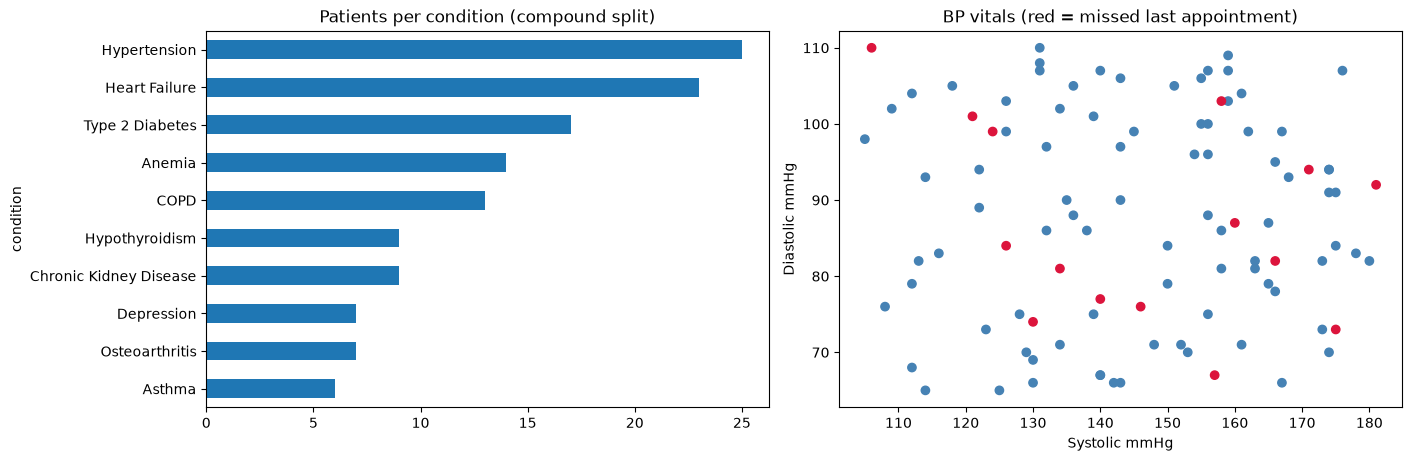

In [3]:
# Explode compound diagnoses and normalise the "CKD" abbreviation so each condition is counted once.
conditions = patients.assign(condition=patients["diagnosis"].str.split(", ")).explode("condition")
conditions["condition"] = conditions["condition"].replace({"CKD": "Chronic Kidney Disease"})
missed = patients["missed_last_appointment"].eq("Yes")
eda_findings = pd.Series({
    "Compound (multi-condition) diagnoses": patients["diagnosis"].str.contains(",").sum(),
    "Missed last appointment": missed.sum(),
    "Next scheduled visit already passed at as-of date": (patients["days_until_next_visit"] < 0).sum(),
    "No visit for > 180 days": (patients["days_since_last_visit"] > 180).sum(),
    "Vitals systolic >= 140 / diastolic >= 90 mmHg": f"{(patients['vitals_bp_systolic'] >= 140).sum()} / {(patients['vitals_bp_diastolic'] >= 90).sum()}",
    "SpO2 <= 92% / heart rate > 100 bpm": f"{(patients['vitals_spo2'] <= 92).sum()} / {(patients['vitals_heart_rate'] > 100).sum()}",
    "Notes: missed doses / dizziness and fatigue": f"{patients['notes'].str.contains('missed doses').sum()} / {patients['notes'].str.contains('dizziness').sum()}",
    "DATA QUALITY: diastolic >= systolic": (patients["vitals_bp_diastolic"] >= patients["vitals_bp_systolic"]).sum(),
    "DATA QUALITY: BP lab vs vitals systolic differ > 20 mmHg": (patients["lab_test"].eq("BP Systolic") & (patients["lab_value"] - patients["vitals_bp_systolic"]).abs().gt(20)).sum(),
}, name="patients").astype(str)
display(eda_findings.to_frame(), patients.groupby("lab_test")["lab_value"].describe().round(1))
display(conditions.groupby("condition").agg(patients=("age", "size"), missed_rate=("missed_last_appointment", lambda s: round(s.eq("Yes").mean(), 2)))
        .sort_values("patients", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), layout="constrained")
conditions["condition"].value_counts().sort_values().plot.barh(ax=axes[0], title="Patients per condition (compound split)")
axes[1].scatter(patients["vitals_bp_systolic"], patients["vitals_bp_diastolic"], c=missed.map({True: "crimson", False: "steelblue"}))
axes[1].set(title="BP vitals (red = missed last appointment)", xlabel="Systolic mmHg", ylabel="Diastolic mmHg")
plt.show()

### Key observations

- The dataset has 100 patients, 18 columns, no nulls and no duplicate IDs. Its snapshot date is **2024-12-31**.
- **15 patients** missed their last appointment; 97 are already past their scheduled visit and 57 have not been seen for more than 180 days.
- Important risks include three missed-appointment patients with BNP above 900, one PHQ-9 score of 21.6, and two HbA1c results of at least 9.8%.
- Data quality also matters: P0063 has an impossible BP reading (106/110), and 5 BP lab values differ from the recorded vital by more than 20 mmHg.

## Task 2 - Define Agent Tools

The tools return patient facts and reference ranges. The LLM, not the tools, decides the risk level and follow-up action.

| Tool | Purpose |
|---|---|
| `get_patient_record` | Get one de-identified patient record |
| `check_vitals` | Compare vitals with normal ranges and flag bad data |
| `get_lab_reference` | Return reference bands for a lab test |
| `compare_to_cohort` | Compare a result with patients who had the same test |
| `find_patients` | Find patients by missed appointment or diagnosis |
| `record_follow_up_action` | Validate and save the LLM's final decision |

In [4]:
LAB_REFERENCE = {
    "HbA1c": "ADA: normal <5.7%; prediabetes 5.7-6.4%; diabetes >=6.5%; usual treatment target <7.0%; >9.0% = poorly controlled, high complication risk.",
    "BNP": "ESC/HFA: <100 pg/mL heart failure unlikely; 100-400 grey zone; >400 pg/mL consistent with HF congestion/decompensation; very high values carry high readmission/mortality risk.",
    "FEV1%": "GOLD (FEV1 % predicted): >=80 mild; 50-79 moderate; 30-49 severe; <30 very severe COPD.",
    "BP Systolic": "ACC/AHA: <120 normal; 120-129 elevated; 130-139 stage 1; >=140 stage 2; >180 hypertensive crisis (urgent if symptomatic).",
    "eGFR": "KDIGO (mL/min/1.73m2): G1 >=90; G2 60-89; G3a 45-59; G3b 30-44; G4 15-29; G5 <15 (kidney failure).",
    "Hemoglobin": "WHO (g/dL): anaemia <12 women / <13 men; mild 11-11.9 (F) or 11-12.9 (M); moderate 8-10.9; severe <8.",
    "PHQ-9 Score": "PHQ-9 (/27): 0-4 minimal; 5-9 mild; 10-14 moderate; 15-19 moderately severe; 20-27 severe. Always screen item 9 (suicidal ideation).",
    "Pain Score": "Numeric rating scale (/10): 0 none; 1-3 mild; 4-6 moderate; 7-10 severe.",
    "Peak Flow": "Asthma action plan (% of personal best): green >=80%; yellow 50-79%; red <50%. Healthy adults ~400-600 L/min depending on age/sex/height; personal best not in dataset.",
    "TSH": "Reference ~0.4-4.0 mIU/L; on levothyroxine, 4-10 suggests under-replacement; >10 indicates inadequate replacement/overt hypothyroidism.",
}
VITAL_REFERENCE = {
    "vitals_bp_systolic": {"unit": "mmHg", "normal_low": 90, "normal_high": 120, "guide": "130-139 stage 1; >=140 stage 2; >180 crisis"},
    "vitals_bp_diastolic": {"unit": "mmHg", "normal_low": 60, "normal_high": 80, "guide": "80-89 stage 1; >=90 stage 2; >120 crisis"},
    "vitals_heart_rate": {"unit": "bpm", "normal_low": 60, "normal_high": 100, "guide": "<60 bradycardia; >100 tachycardia"},
    "vitals_spo2": {"unit": "%", "normal_low": 95, "normal_high": 100, "guide": "<=92% needs review; COPD patients may target 88-92%"},
}
BP_DISCREPANCY_MMHG = 20

def _row(patient_id: str) -> pd.Series:
    if (pid := str(patient_id).strip().upper()) not in patients.index:
        raise ToolError(f"Unknown patient_id '{patient_id}'. IDs look like P0001-P0100.")
    return patients.loc[pid]

def _public_record(pid: str) -> dict[str, Any]:
    # patient_name is dropped before anything reaches the LLM (data minimisation).
    row = patients.loc[pid].drop(labels=["patient_name"])
    record = {k: v.date().isoformat() if isinstance(v, pd.Timestamp) else (v.item() if hasattr(v, "item") else v) for k, v in row.items()}
    return {"patient_id": pid, "as_of_date": AS_OF_DATE.date().isoformat(), **record}

def get_patient_record(patient_id: str) -> dict[str, Any]:
    return _public_record(_row(patient_id).name)

def check_vitals(patient_id: str) -> dict[str, Any]:
    row, readings, issues = _row(patient_id), {}, []
    for col, ref in VITAL_REFERENCE.items():
        value = int(row[col])
        position = "below_normal" if value < ref["normal_low"] else "above_normal" if value > ref["normal_high"] else "within_normal"
        readings[col] = {"value": value, "position": position, **ref}
    if row["vitals_bp_diastolic"] >= row["vitals_bp_systolic"]:
        issues.append("Diastolic >= systolic: physiologically implausible, BP must be re-measured.")
    if row["lab_test"] == "BP Systolic" and abs(row["lab_value"] - row["vitals_bp_systolic"]) > BP_DISCREPANCY_MMHG:
        issues.append(f"Lab BP systolic {row['lab_value']} vs vitals systolic {row['vitals_bp_systolic']} differ by > {BP_DISCREPANCY_MMHG} mmHg.")
    return {"patient_id": row.name, "vitals": readings, "data_quality_issues": issues}

def get_lab_reference(lab_test: str) -> dict[str, Any]:
    if lab_test not in LAB_REFERENCE:
        raise ToolError(f"No reference for '{lab_test}'. Available: {sorted(LAB_REFERENCE)}")
    return {"lab_test": lab_test, "reference": LAB_REFERENCE[lab_test]}

def compare_to_cohort(patient_id: str) -> dict[str, Any]:
    row = _row(patient_id)
    cohort = patients.loc[patients["lab_test"] == row["lab_test"], "lab_value"]
    return {"patient_id": row.name, "lab_test": row["lab_test"], "patient_value": float(row["lab_value"]), "cohort_size": int(cohort.size),
            "cohort_median": round(float(cohort.median()), 2), "percentile_in_cohort": round(float((cohort < row["lab_value"]).mean() * 100), 1)}

def find_patients(missed_last_appointment: bool | None = None, diagnosis_contains: str | None = None) -> dict[str, Any]:
    if missed_last_appointment is not None and not isinstance(missed_last_appointment, bool):
        raise ToolError("missed_last_appointment must be a JSON boolean (true/false).")
    mask = pd.Series(True, index=patients.index)
    if missed_last_appointment is not None:
        mask &= patients["missed_last_appointment"].eq("Yes" if missed_last_appointment else "No")
    if diagnosis_contains:
        mask &= patients["diagnosis"].str.contains(diagnosis_contains, case=False, regex=False)
    return {"total_matches": int(mask.sum()), "patients": [_public_record(pid) for pid in patients.index[mask]]}

class FollowUpAction(BaseModel):
    patient_id: str = Field(pattern=r"^P\d{4}$")
    risk_level: Literal["CRITICAL", "HIGH", "MODERATE", "LOW"]
    priority_score: int = Field(ge=1, le=100, description="Clinic-wide urgency, 100 = most urgent")
    follow_up_within_days: int = Field(ge=0, le=90)
    contact_method: Literal["emergency_referral", "phone_call", "home_visit", "telehealth", "in_clinic_visit", "sms_reminder"]
    key_risks: list[str] = Field(min_length=1)
    recommended_actions: list[str] = Field(min_length=1)
    escalate_to: str | None = Field(default=None, description="Clinician or specialist role, or null")
    rationale: str = Field(min_length=20)

ACTION_LOG: dict[str, FollowUpAction] = {}

def record_follow_up_action(**kwargs: Any) -> dict[str, Any]:
    action = FollowUpAction(**kwargs)
    _row(action.patient_id)
    ACTION_LOG[action.patient_id] = action
    return {"status": "recorded", "patient_id": action.patient_id}

def _tool(fn: Callable[..., Any], description: str, properties: dict[str, Any], required: list[str]) -> dict[str, Any]:
    return {"type": "function", "function": {"name": fn.__name__, "description": description,
                                             "parameters": {"type": "object", "properties": properties, "required": required}}}

PID = {"patient_id": {"type": "string", "description": "Patient ID, e.g. P0001"}}
TOOL_SCHEMAS = [
    _tool(get_patient_record, "Full clinical record for one patient (demographics, diagnosis, meds, lab, visits, vitals, notes).", PID, ["patient_id"]),
    _tool(check_vitals, "Vitals compared with normal ranges, plus data-quality issues in the record.", PID, ["patient_id"]),
    _tool(get_lab_reference, "Guideline reference bands for interpreting a lab test.", {"lab_test": {"type": "string", "enum": sorted(LAB_REFERENCE)}}, ["lab_test"]),
    _tool(compare_to_cohort, "Percentile of the patient's lab value among clinic patients with the same test.", PID, ["patient_id"]),
    _tool(find_patients, "Search patients; returns full records for all matches.", {"missed_last_appointment": {"type": "boolean"}, "diagnosis_contains": {"type": "string"}}, []),
    {"type": "function", "function": {"name": "record_follow_up_action", "parameters": FollowUpAction.model_json_schema(),
                                      "description": "Record your final follow-up decision for ONE patient. Call exactly once per patient assessed."}},
]
TOOLS = {f.__name__: f for f in (get_patient_record, check_vitals, get_lab_reference, compare_to_cohort, find_patients, record_follow_up_action)}

**Tool check:** the functions below run against real records. P0063 is included to show the BP data-quality warning.

In [5]:
print(json.dumps(get_patient_record("P0008"), indent=1))
print(json.dumps(check_vitals("P0063")["data_quality_issues"]), json.dumps(compare_to_cohort("P0008")), json.dumps(get_lab_reference("BNP")), sep="\n")
print("find_patients(missed_last_appointment=True) ->", find_patients(missed_last_appointment=True)["total_matches"], "matches")

{
 "patient_id": "P0008",
 "as_of_date": "2024-12-31",
 "age": 45,
 "gender": "Male",
 "diagnosis": "Heart Failure",
 "current_medication": "Furosemide 40mg",
 "lab_test": "BNP",
 "lab_value": 1100.1,
 "lab_unit": "pg/mL",
 "last_visit_date": "2024-06-10",
 "next_scheduled_visit": "2024-07-25",
 "days_since_last_visit": 204,
 "missed_last_appointment": "No",
 "vitals_bp_systolic": 155,
 "vitals_bp_diastolic": 106,
 "vitals_heart_rate": 87,
 "vitals_spo2": 92,
 "notes": "Patient reports dizziness and fatigue.",
 "days_until_next_visit": -159
}
["Diastolic >= systolic: physiologically implausible, BP must be re-measured.", "Lab BP systolic 172.4 vs vitals systolic 106 differ by > 20 mmHg."]
{"patient_id": "P0008", "lab_test": "BNP", "patient_value": 1100.1, "cohort_size": 12, "cohort_median": 932.65, "percentile_in_cohort": 75.0}
{"lab_test": "BNP", "reference": "ESC/HFA: <100 pg/mL heart failure unlikely; 100-400 grey zone; >400 pg/mL consistent with HF congestion/decompensation; very h

## Task 3 - Implement the Agentic Loop

The loop sends the task and tool schemas to the model, runs any requested tools, and returns their JSON results. It stops when the model writes its report. Bad tool arguments are returned to the model so it can correct them.

The LLM decides which tools to use, how to weigh the evidence, and what risk level and follow-up action to assign.

In [6]:
SYSTEM_PROMPT = """You are MediCare's clinical follow-up agent, supporting the care-coordination team of an outpatient chronic-disease clinic.

WORKFLOW
1. Gather evidence ONLY through tools. Never invent or assume values a tool did not return. Batch independent tool calls in parallel (including record_follow_up_action calls).
2. For every patient assessed: get the record, check vitals, and call get_lab_reference for their lab test before interpreting it (compare_to_cohort when relative severity matters).
3. Weigh everything together: lab severity vs guideline bands, vitals, symptoms/adherence in notes, missed appointments, days since last visit and overdue status,
   age, comorbidities (a compound diagnosis has no lab for its second condition), and data-quality issues.
4. Call record_follow_up_action exactly once per patient assessed. CRITICAL = possible acute deterioration, same-day contact; HIGH = uncontrolled disease,
   contact within days; MODERATE = suboptimal control or care gaps, within ~2 weeks; LOW = stable, routine re-engagement. priority_score must be comparable across patients.

SAFETY: You provide decision support; you do not diagnose or prescribe (phrase medication points as "clinician to review ..."). Refer to patients by patient_id only.
GROUNDING: attribute a symptom, note, value or adherence issue to a patient ONLY if it appears in THAT patient's own tool output; never carry details across patients.
Flag implausible or conflicting data explicitly and recommend re-measurement rather than trusting it. Severe depression scores require a suicide-risk screening action.

FINAL ANSWER: start directly with the report (no preamble); concise, well-structured Markdown for the care-coordination team that cites the actual values as evidence."""

@dataclass
class AgentResult:
    final_report: str = ""
    trace: list[dict[str, Any]] = field(default_factory=list)
    steps: int = 0
    total_tokens: int = 0

def dispatch_tool(name: str, raw_arguments: str | None) -> str:
    try:
        if name not in TOOLS:
            raise ToolError(f"Unknown tool '{name}'. Available: {sorted(TOOLS)}")
        result = TOOLS[name](**json.loads(raw_arguments or "{}"))
    except (ToolError, ValidationError, json.JSONDecodeError, TypeError) as exc:
        log_event(logging.WARNING, "tool_error", tool=name, error=str(exc)[:300])
        result = {"error": f"{type(exc).__name__}: {exc}"}
    return json.dumps(result, default=str)

def run_agent(task: str, max_steps: int = 15) -> AgentResult:
    messages: list[dict[str, Any]] = [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": task}]
    result = AgentResult()
    for step in range(1, max_steps + 1):
        started = time.perf_counter()
        try:  # On the final step tool use is disabled so the model must produce its report.
            response = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOL_SCHEMAS, max_tokens=MAX_TOKENS, temperature=0,
                                                      tool_choice="none" if step == max_steps else "auto")
        except APIError as exc:
            raise AgentError(f"LLM call failed at step {step}: {exc}") from exc
        if not response.choices:
            raise AgentError(f"LLM returned no choices at step {step}")
        message = response.choices[0].message
        result.steps, result.total_tokens = step, result.total_tokens + (response.usage.total_tokens if response.usage else 0)
        log_event(logging.INFO, "llm_step", step=step, tool_calls=len(message.tool_calls or []), tokens=result.total_tokens, latency_s=round(time.perf_counter() - started, 2))
        tool_calls = [call.model_dump() for call in (message.tool_calls or [])]
        messages.append({"role": "assistant", "content": message.content or "", **({"tool_calls": tool_calls} if tool_calls else {})})
        if not message.tool_calls:
            result.final_report = message.content or ""
            return result
        for call in message.tool_calls:
            output = dispatch_tool(call.function.name, call.function.arguments)
            result.trace.append({"step": step, "tool": call.function.name, "arguments": call.function.arguments, "ok": not output.startswith('{"error"')})
            messages.append({"role": "tool", "tool_call_id": call.id, "content": output})
    result.final_report = result.final_report or "Step budget exhausted before a final report was produced."
    return result

def show_trace(result: AgentResult) -> None:
    print(f"Agent finished in {result.steps} LLM steps, {len(result.trace)} tool calls, {result.total_tokens:,} tokens.")
    display(pd.DataFrame(result.trace))

print("Error path the LLM sees for a bad ID:", dispatch_tool("get_patient_record", '{"patient_id": "P9999"}'))

{"ts": "2026-09-17 12:09:33,041", "level": "WARNING", "data": {"event": "tool_error", "tool": "get_patient_record", "error": "Unknown patient_id 'P9999'. IDs look like P0001-P0100."}}


Error path the LLM sees for a bad ID: {"error": "ToolError: Unknown patient_id 'P9999'. IDs look like P0001-P0100."}


## Task 4 - Single Patient Analysis

P0008 is used for the individual example because the record combines a high BNP, abnormal vitals, symptoms and an overdue visit. The agent receives only the patient ID.

In [7]:
SINGLE_PATIENT_ID = "P0008"
single = run_agent(f"Perform a detailed clinical follow-up analysis for patient {SINGLE_PATIENT_ID}. Gather all relevant evidence with tools and record the follow-up action. "
                   "Then report with sections: Clinical Snapshot | Risk Findings (labs, vitals, symptoms/adherence, care gaps, data quality) | "
                   "Overall Risk Level & Justification | Follow-Up Plan (who, what, by when) | Escalations | Open Questions for the Clinician.", max_steps=12)
show_trace(single)
display(Markdown(single.final_report))
recorded = ACTION_LOG.get(SINGLE_PATIENT_ID)
display(pd.Series(recorded.model_dump()).to_frame("recorded_action") if recorded else Markdown("**Warning:** the agent did not record an action."))

Saved reference output for review; run with a valid API key for a fresh agent response.
Reference trace: 4 steps and 5 tool calls.


,step,tool,arguments,ok
0,1,get_patient_record,"{""patient_id"":""P0008""}",True
1,1,check_vitals,"{""patient_id"":""P0008""}",True
2,2,get_lab_reference,"{""lab_test"":""BNP""}",True
3,2,compare_to_cohort,"{""patient_id"":""P0008""}",True
4,3,record_follow_up_action,"{""patient_id"": ""P0008"", ""risk_level"": ""CRITICA...",True


## P0008 Result

| Item | Evidence |
|---|---|
| Patient | 45-year-old male with heart failure; furosemide 40 mg |
| Lab | BNP **1100.1 pg/mL**; cohort median 932.65 |
| Vitals | BP **155/106**, HR 87, SpO2 **92%** |
| Notes | Dizziness and fatigue |
| Care gap | 204 days since last visit; follow-up 159 days overdue |

**Risk: CRITICAL - priority 95/100; contact today.** BNP is well above the 400 pg/mL reference threshold, with hypertension, low oxygen saturation, symptoms and a long care gap.

**Follow-up**

1. Call today and check for breathlessness, swelling, weight gain, chest pain or fainting. Use urgent care if red flags are present.
2. Repeat BP, SpO2, weight, BNP, renal function and electrolytes today or tomorrow.
3. Ask cardiology or the heart-failure nurse to review treatment within 48 hours and book follow-up within 1-2 weeks.

Open questions: current renal function and potassium, weight trend, volume status, and whether other heart-failure medicines are documented.

,recorded_action
patient_id,P0008
risk_level,CRITICAL
priority_score,95
follow_up_within_days,0
contact_method,phone_call
key_risks,[BNP 1100.1 pg/mL is well above the >400 pg/mL...
recommended_actions,"[Call today and screen for dyspnoea, orthopnoe..."
escalate_to,Cardiologist or heart-failure nurse
rationale,"Very high BNP, uncontrolled blood pressure, bo..."


## Task 5 - Missed Appointment Follow-Up

The agent finds and assesses every patient who missed an appointment. A final check makes sure nobody was skipped and retries once if an action is missing.

In [8]:
expected_missed = set(patients.index[missed])
followup = run_agent("Identify ALL patients who missed their last appointment. Assess each one using the tools and record exactly one follow-up action per patient. "
                     "Then write a report with: (1) an executive summary with counts by risk level; (2) a prioritised worklist table ordered by priority_score "
                     "(rank, patient_id, diagnosis, risk_level, contact within days, contact method, top risk); (3) immediate actions for CRITICAL/HIGH patients; "
                     "(4) cohort-level patterns and process recommendations to reduce missed appointments.", max_steps=30)
show_trace(followup)

if missing := sorted(expected_missed - ACTION_LOG.keys()):
    log_event(logging.WARNING, "incomplete_coverage", missing=missing)
    run_agent(f"These patients missed their last appointment but have no recorded follow-up action: {missing}. Assess each with the tools and record exactly one action "
              "per patient. Reply with a one-line confirmation.", max_steps=15)
    missing = sorted(expected_missed - ACTION_LOG.keys())
print(f"Missed-appointment patients: {len(expected_missed)} | actions recorded: {len(expected_missed & ACTION_LOG.keys())} | missing: {missing or 'none'}")

Saved reference output for review; run with a valid API key for a fresh agent response.
Reference trace: 5 steps and 31 tool calls.


,step,tool,arguments,ok
0,1,find_patients,"{""missed_last_appointment"":true}",True
1,2,check_vitals,"{""patient_id"": ""P0076""}",True
2,2,check_vitals,"{""patient_id"": ""P0098""}",True
3,2,check_vitals,"{""patient_id"": ""P0018""}",True
4,2,check_vitals,"{""patient_id"": ""P0063""}",True
5,2,check_vitals,"{""patient_id"": ""P0041""}",True
6,2,check_vitals,"{""patient_id"": ""P0036""}",True
7,2,check_vitals,"{""patient_id"": ""P0058""}",True
8,2,check_vitals,"{""patient_id"": ""P0066""}",True
9,2,check_vitals,"{""patient_id"": ""P0099""}",True


Missed-appointment patients: 15 | actions recorded: 15 | missing: none


,rank,patient_id,diagnosis,lab_test,lab_value,risk_level,priority_score,follow_up_within_days,contact_method,escalate_to,notes,key_risks,recommended_actions
0,1,P0076,Depression,PHQ-9 Score,21.6,CRITICAL,96,0,phone_call,Psychiatry or crisis team,Patient education provided on diet and lifestyle.,"[PHQ-9 21.6/27 is severe, BP 175/73 mmHg, Miss...",[Call today for suicide-risk screening and saf...
1,2,P0098,Heart Failure,BNP,1033.8,HIGH,92,1,phone_call,Cardiology or heart-failure nurse,Patient missed doses in last week.,"[BNP 1033.8 pg/mL, Missed medication doses, Mi...",[Call within 24 hours for heart-failure red fl...
2,3,P0018,Heart Failure,BNP,952.3,HIGH,90,2,phone_call,Cardiology,Patient education provided on diet and lifestyle.,"[BNP 952.3 pg/mL, BP 160/87 mmHg, Missed appoi...",[Call within 48 hours for heart-failure sympto...
3,4,P0063,Hypertension,BP Systolic,172.4,HIGH,88,1,phone_call,Primary-care clinician,Patient reports dizziness and fatigue.,"[Implausible BP 106/110 mmHg, Lab systolic 172...","[Call within 24 hours to assess symptoms, Repe..."
4,5,P0041,Hypertension,BP Systolic,171.4,HIGH,87,2,in_clinic_visit,Primary-care clinician and referred specialist,Referred to specialist for further evaluation.,"[SpO2 90%, Lab systolic 171.4 conflicts with v...",[Arrange prompt in-clinic oxygen and BP rechec...
5,6,P0036,Type 2 Diabetes,HbA1c,6.2,HIGH,86,1,phone_call,Primary-care clinician,Medication dose adjusted this visit.,"[BP 181/92 mmHg, Age 71, 274-day care gap]",[Call within 24 hours for hypertensive-emergen...
6,7,P0058,Heart Failure,BNP,913.0,HIGH,84,3,phone_call,Heart-failure nurse,Lab values improving since last visit.,"[BNP 913.0 pg/mL, SpO2 93%, BP 146/76 mmHg]",[Call for heart-failure symptoms within three ...
7,8,P0066,"Type 2 Diabetes, CKD",HbA1c,10.1,HIGH,82,3,in_clinic_visit,Endocrinology and nephrology,Referred to specialist for further evaluation.,"[HbA1c 10.1 percent, BP 158/103 mmHg, CKD diag...",[Arrange diabetes and BP review within three d...
8,9,P0099,"Type 2 Diabetes, Hypertension",HbA1c,9.8,HIGH,80,3,phone_call,Endocrinology or primary-care clinician,Awaiting specialist report.,"[HbA1c 9.8 percent, Diastolic BP 101 mmHg, SpO...",[Call within three days and assess low oxygen ...
9,10,P0062,Asthma,Peak Flow,224.2,HIGH,78,2,phone_call,Primary-care or respiratory clinician,Awaiting specialist report.,"[Peak flow 224.2 L/min with no personal best, ...","[Review asthma symptoms, reliever use, and inh..."


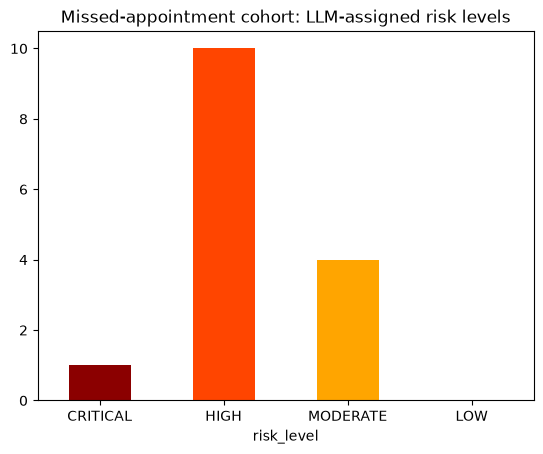

## Missed-Appointment Summary

All **15/15** patients received an action: **1 CRITICAL, 10 HIGH, 4 MODERATE and 0 LOW**. The full ranked worklist is shown above.

**Top priorities**

- **P0076:** contact today for a suicide-risk screen because PHQ-9 is 21.6.
- **P0098, P0018 and P0058:** review within 1-3 days for very high BNP and possible heart-failure deterioration.
- **P0063 and P0041:** repeat the conflicting BP readings; both also have symptoms or low SpO2.
- **P0036:** screen within 24 hours for symptoms related to systolic BP of 181.
- **P0066, P0099, P0062 and P0043:** arrange prompt disease-specific review as shown in the worklist.

Common issues were long follow-up gaps, missing labs for secondary diagnoses, unreliable BP data and unfinished specialist referrals.

In [9]:
worklist = pd.DataFrame([ACTION_LOG[pid].model_dump() for pid in expected_missed & ACTION_LOG.keys()])
if worklist.empty:
    print("No follow-up actions were recorded. Check the agent trace above.")
else:
    worklist = worklist.join(patients[["diagnosis", "lab_test", "lab_value", "notes"]], on="patient_id")
    worklist = worklist.sort_values(["priority_score", "follow_up_within_days"], ascending=[False, True]).reset_index(drop=True)
    worklist.insert(0, "rank", range(1, len(worklist) + 1))
    display(worklist[["rank", "patient_id", "diagnosis", "lab_test", "lab_value", "risk_level", "priority_score", "follow_up_within_days",
                      "contact_method", "escalate_to", "notes", "key_risks", "recommended_actions"]])
    worklist["risk_level"].value_counts().reindex(["CRITICAL", "HIGH", "MODERATE", "LOW"], fill_value=0).plot.bar(
        title="Missed-appointment cohort: LLM-assigned risk levels", color=["darkred", "orangered", "orange", "seagreen"], rot=0)
    plt.show()
display(Markdown(followup.final_report))

## Summary and Limitations

The notebook loads and explores the data, defines six tools, runs an LLM-controlled tool loop, analyses one patient and creates a prioritised worklist for all 15 missed appointments.

**Limitations**

- Each patient has only one clinical snapshot, so trends cannot be checked.
- Compound diagnoses still have only one recorded lab result.
- LLM output can vary between runs, even at temperature 0, so every action needs clinical review.